#  ----------------------------taco delivery dataset analysis------------------------------

###  🧹 Data Cleaning tasks
###   1-Are there any missing values in the dataset?
###   2-Are the data types appropriate (e.g., are time columns in datetime format)?
###   3-Are there any duplicate orders (based on Order ID)?
###   4-Are there outliers in Delivery Duration (min), Price ($), Tip ($), or Distance (km)?
###   5-Are all values in Taco Size and Taco Type consistent (e.g., no typos or casing issues)?

#  louading data

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy.stats import ttest_ind
import statsmodels.formula.api as smf
from scipy.stats import ttest_ind

plt.style.use('fivethirtyeight')

In [23]:
df=pd.read_csv(r"C:\Users\adelo\Downloads\taco_sales_(2024-2025).csv")

In [4]:
df.head()

,Order ID,Restaurant Name,Location,Order Time,Delivery Time,Delivery Duration (min),Taco Size,Taco Type,Toppings Count,Distance (km),Price ($),Tip ($),Weekend Order
0,770487,El Taco Loco,New York,01-08-2024 14:55,01-08-2024 15:36,41,Regular,Chicken Taco,5,3.01,9.25,2.22,False
1,671858,El Taco Loco,San Antonio,23-11-2024 17:11,23-11-2024 17:25,14,Regular,Beef Taco,1,6.20,4.25,3.01,True
2,688508,Taco Haven,Austin,21-11-2024 20:24,21-11-2024 21:02,38,Large,Pork Taco,2,20.33,7.00,0.02,False
3,944962,Spicy Taco House,Dallas,21-09-2024 06:43,21-09-2024 07:28,45,Regular,Chicken Taco,2,3.00,5.50,1.90,True
4,476417,Casa del Taco,San Antonio,24-07-2024 11:01,24-07-2024 11:16,15,Large,Pork Taco,0,24.34,4.50,1.14,False


In [5]:
# 1

null_val=df.isnull().sum().sum()
if null_val ==0 :
    print('there is no missing values in the data') 
else: print('there is',null_val,' missing values')

there is no missing values in the data


In [6]:
# 2
df.info()


df['Order Time']=pd.to_datetime(df['Order Time'], format="%d-%m-%Y %H:%M")
df['Delivery Time']=pd.to_datetime(df['Delivery Time'], format="%d-%m-%Y %H:%M")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order ID                 1000 non-null   int64  
 1   Restaurant Name          1000 non-null   object 
 2   Location                 1000 non-null   object 
 3   Order Time               1000 non-null   object 
 4   Delivery Time            1000 non-null   object 
 5   Delivery Duration (min)  1000 non-null   int64  
 6   Taco Size                1000 non-null   object 
 7   Taco Type                1000 non-null   object 
 8   Toppings Count           1000 non-null   int64  
 9   Distance (km)            1000 non-null   float64
 10  Price ($)                1000 non-null   float64
 11  Tip ($)                  1000 non-null   float64
 12  Weekend Order            1000 non-null   bool   
dtypes: bool(1), float64(3), int64(3), object(6)
memory usage: 94.9+ KB


In [7]:
# 3
duplicated_val=df.duplicated().sum()
if null_val ==0 :
    print('there is no duplicated values in the data') 
else: print('there is',duplicated_val,' dublicated values')

there is no duplicated values in the data


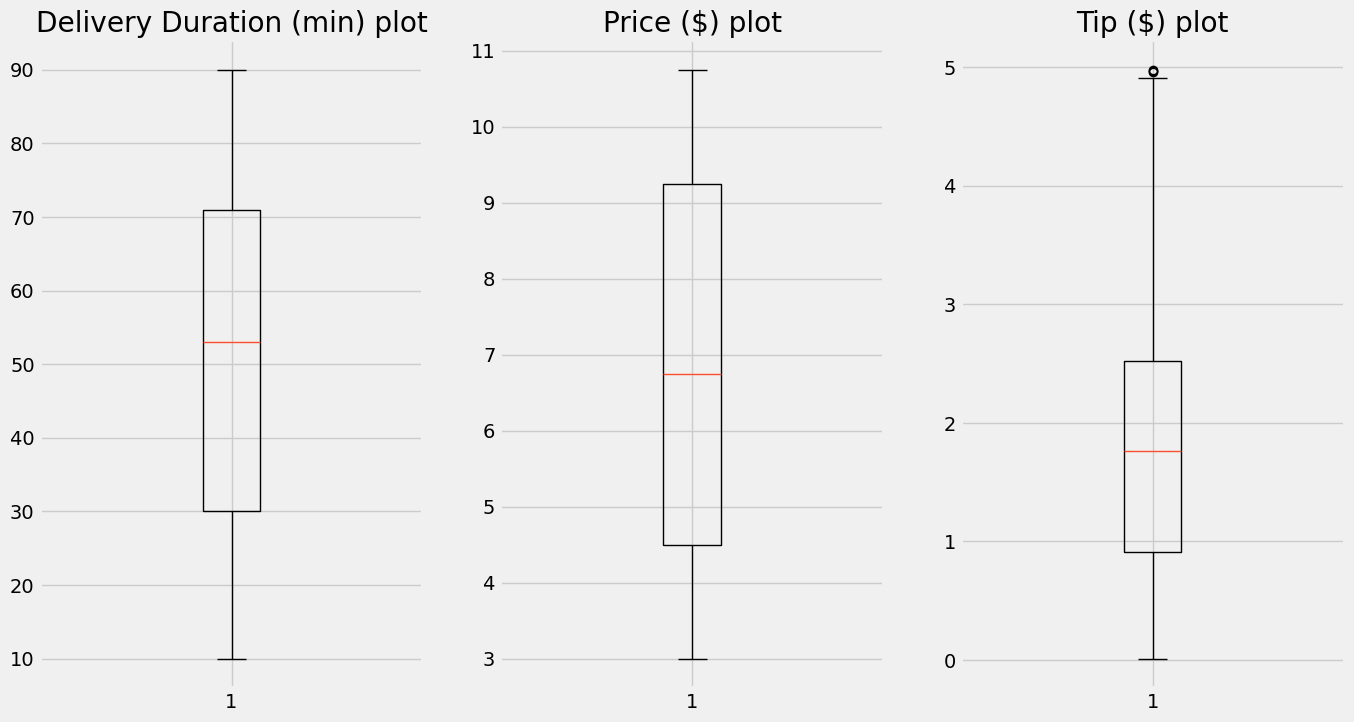

there is  0  outlier in  Delivery Duration (min) variable
there is  49  outlier in  Tip ($) variable
there is  0  outlier in  Price ($) variable


In [10]:
# # 4

df.describe()[['Delivery Duration (min)','Price ($)','Tip ($)']]


fig,ax=plt.subplots(1,3,figsize=(15,8))
ax[0].boxplot(df['Delivery Duration (min)'])
ax[0].set_title('Delivery Duration (min) plot')
ax[1].boxplot(df['Price ($)'])
ax[1].set_title('Price ($) plot')
ax[2].boxplot(df['Tip ($)'])
ax[2].set_title('Tip ($) plot')
plt.show()


cols=['Delivery Duration (min)','Tip ($)','Price ($)']
for col in cols :
    mean = df[col].mean()
    std = df[col].std()
    outliers = (df[col] < mean - 2*std) | (df[col] > mean + 2*std)
    print('there is ',outliers.sum(),' outlier in ',col,'variable')
        

In [11]:
# # 5

print(df['Taco Size'].unique())
print(df['Taco Type'].unique())



['Regular' 'Large']
['Chicken Taco' 'Beef Taco' 'Pork Taco' 'Veggie Taco' 'Fish Taco']


## 📊 Data Exploration tasks
### 6-What are the most common taco types and sizes?
### 7-What is the average delivery duration overall? Does it differ by taco size or type?
### 8-Which restaurants have the fastest or slowest delivery times?
### 9-What is the distribution of Toppings Count? Do customers usually choose many or few toppings?
### 10-How far do deliveries usually travel?
 

In [12]:
# 6

taco_col=['Taco Type','Taco Size']
for col in taco_col:
    print('most common ',col,'is', df[col].value_counts(ascending=False).reset_index()[col][0])

most common  Taco Type is Chicken Taco
most common  Taco Size is Regular


In [13]:
# 7

print('the average delivery duration is ',df['Delivery Duration (min)'].mean(),'min')

df.groupby('Taco Type')['Delivery Duration (min)'].mean()

df.groupby('Taco Size')['Delivery Duration (min)'].mean()

the average delivery duration is  50.93 min


Taco Size
Large      50.349398
Regular    51.505976
Name: Delivery Duration (min), dtype: float64

In [14]:
# 8

resturant=df.groupby('Restaurant Name')['Delivery Duration (min)'].mean().sort_values(ascending=True).reset_index()

print('the fastest resturant in delivery is ',resturant['Restaurant Name'][0],'with ',round(resturant['Delivery Duration (min)'][0]),'min average delivery time')

resturant_slowest=df.groupby('Restaurant Name')['Delivery Duration (min)'].mean().sort_values(ascending=False).reset_index()

print('the slowesst resturant in delivery is ',resturant_slowest['Restaurant Name'][0],'with ',round(resturant_slowest['Delivery Duration (min)'][0]),'min average delivery time')

the fastest resturant in delivery is  La Vida Taco with  47 min average delivery time
the slowesst resturant in delivery is  The Taco Stand with  54 min average delivery time


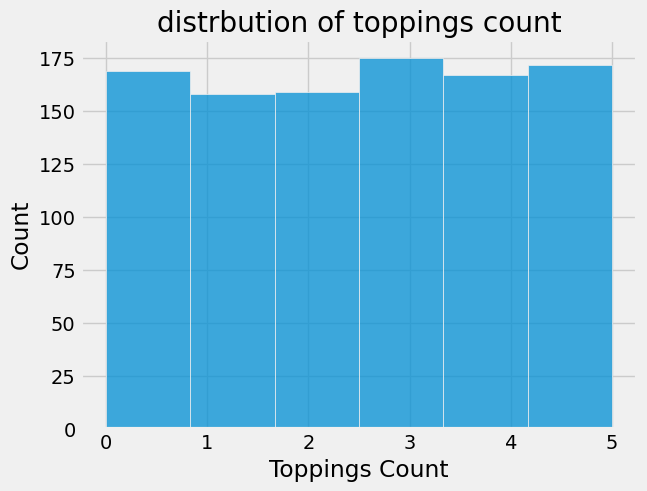

count    1000.000000
mean        2.529000
std         1.717005
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Toppings Count, dtype: float64

In [15]:
# 9

sns.histplot(df['Toppings Count'], bins=6)
plt.title('distrbution of toppings count')
plt.show()

df['Toppings Count'].value_counts()

df['Toppings Count'].describe()

<Axes: xlabel='Distance (km)', ylabel='Count'>

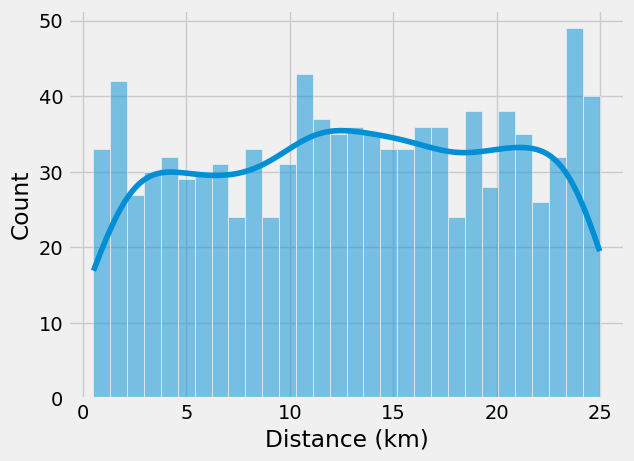

In [16]:
# 10

df['Distance (km)'].describe()

sns.histplot(df['Distance (km)'], bins=30, kde=True)

## 💲 Price & Tip Analysis 
### 11-What is the average price of an order?
### 12-Is there a relationship between price and tip amount?
### 13-Do customers tip more on weekends?
### 14-Does the number of toppings or taco size affect the price significantly?

In [18]:
# 11

print('the average price of order is ',round(df['Price ($)'].mean(),2),'$')

the average price of order is  6.91 $


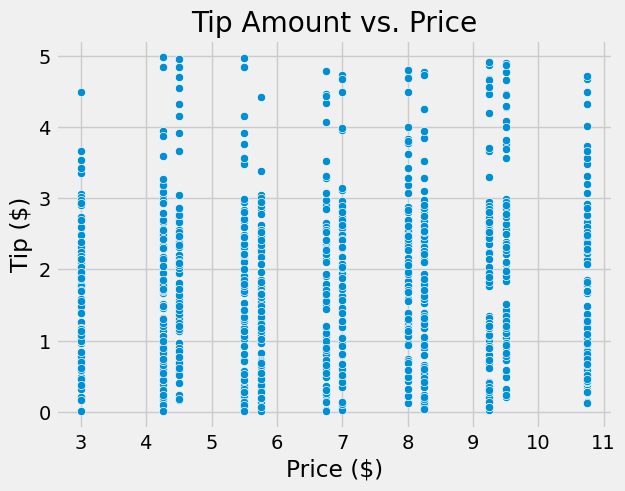

the correlation value is  0.059


In [21]:
# 12

sns.scatterplot(data=df, x='Price ($)', y='Tip ($)')
plt.title('Tip Amount vs. Price')
plt.xlabel('Price ($)')
plt.ylabel('Tip ($)')
plt.show()

print('the correlation value is ', round(df['Price ($)'].corr(df['Tip ($)']),3))

T-statistic: 11.20, p-value: 0.000


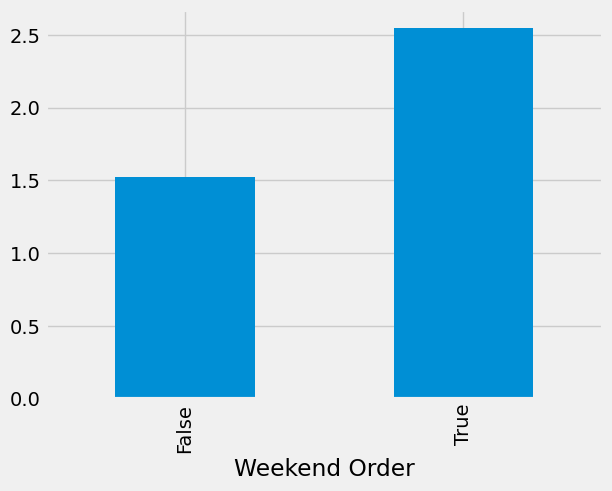

In [24]:
# 13

df.groupby('Weekend Order')['Tip ($)'].mean()

df.groupby('Weekend Order')['Tip ($)'].mean().plot(kind='bar')


weekend_tips = df[df['Weekend Order'] == True]['Tip ($)']
weekday_tips = df[df['Weekend Order'] == False]['Tip ($)']

t_stat, p_val = ttest_ind(weekend_tips, weekday_tips, equal_var=False)
print(f"T-statistic: {t_stat:.2f}, p-value: {p_val:.3f}")

In [26]:
# 14

df.groupby('Toppings Count')['Price ($)'].mean().sort_values(ascending=False)

print('the correlation value ',df['Toppings Count'].corr(df['Price ($)']))

df.groupby('Taco Size')['Price ($)'].mean().sort_values(ascending=False)


# Make sure categorical variable is treated properly
model = smf.ols('Q("Price ($)") ~ Q("Toppings Count") + C(Q("Taco Size"))', data=df).fit()
print(model.summary())

the correlation value  0.9459276310056249
                            OLS Regression Results                            
Dep. Variable:         Q("Price ($)")   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.046e+32
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        18:08:43   Log-Likelihood:                 32037.
No. Observations:                1000   AIC:                        -6.407e+04
Df Residuals:                     997   BIC:                        -6.405e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

## 📆 Time-Based & Weekend 
### 15-Are orders more frequent on weekends vs weekdays?
### 16-At what times of day are most orders placed?
### 17-Is delivery slower on weekends?
### 18-Do customers order more tacos or toppings on weekends?

In [27]:
# 15

df['Weekend Order'].value_counts(normalize=True)*100

Weekend Order
False    72.5
True     27.5
Name: proportion, dtype: float64

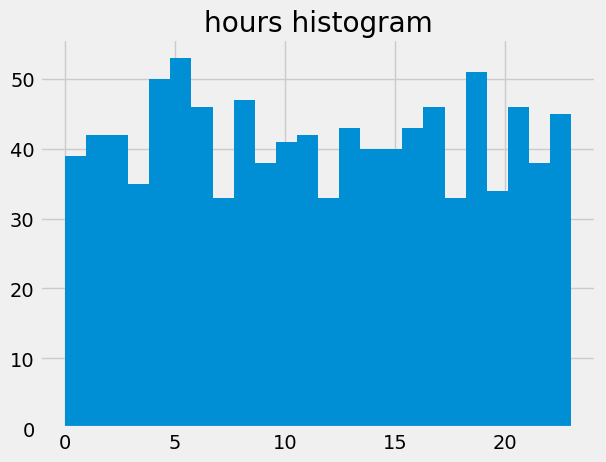

count    1000.000000
mean       11.458000
std         6.949859
min         0.000000
25%         5.000000
50%        11.000000
75%        17.000000
max        23.000000
Name: order hour, dtype: float64

In [55]:
# 16
df['Delivery Time']= pd.to_datetime(df['Delivery Time'],format='%d-%m-%Y %H:%M')
df['order hour']=df['Delivery Time'].dt.hour


plt.hist(x=df['order hour'],bins=24)
plt.title('hours histogram')
plt.show()

df['order hour'].value_counts()

df['order hour'].describe()

In [61]:
df['Order Time']=pd.to_datetime(df['Order Time'],format="%d-%m-%Y %H:%M")

In [64]:
# 17

df['delivery time in min']=round(df['Delivery Time']-df['Order Time'])

df.groupby('Weekend Order')['delivery time in min'].mean()

Weekend Order
False   0 days 00:51:32.275862068
True    0 days 00:49:19.636363636
Name: delivery time in min, dtype: timedelta64[ns]

In [78]:
# 18
df.groupby('Weekend Order').agg(toping_rate=("Toppings Count", "mean"))

weekend = df[df['Weekend Order'] == True]['Toppings Count']
weekday = df[df['Weekend Order'] == False]['Toppings Count']

t_stat, p_val = ttest_ind(weekend, weekday, equal_var=False)
print(f"T-test: t={t_stat:.2f}, p={p_val:.4f}")


T-test: t=0.42, p=0.6750
